### Pacotes importados

## Chapter 13: Quasi-Newton methods

### Algorithm 13.1: Quasi-Newton BFGS method

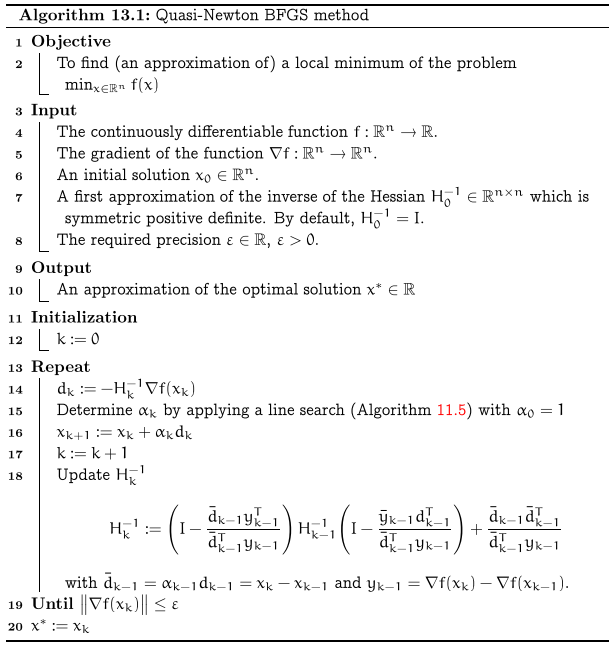

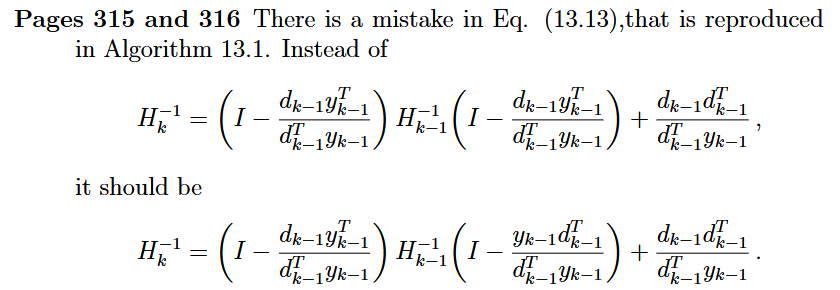

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$

Algoritmo 13.1 - Método Quasi-Newton BFGS
Ponto inicial: [1.0, 1.0]
Iteração |      x1       |      x2       |      f(x)      |   ||grad||   |   α
       0 |    1.00000000 |    1.00000000 |  1.04030e+00 |  1.75517e+00 |   1.0000
       1 |   -0.54030231 |    1.84147098 |  2.90430e-01 |  9.60942e-01 |   1.0000
       2 |   -0.01890093 |    1.50527762 | -1.05886e-03 |  5.02450e-02 |   1.0000
Aviso: yᵀs <= 0. Reiniciando Hinv = I.
       3 |   -0.05438912 |    1.48061581 | -3.41911e-03 |  6.48574e-02 |   1.0000
Aviso: yᵀs <= 0. Reiniciando Hinv = I.
       4 |   -0.09005833 |    1.42644770 | -8.89945e-03 |  1.04096e-01 |   1.0000
Aviso: yᵀs <= 0. Reiniciando Hinv = I.
       5 |   -0.14384786 |    1.33732599 | -2.29338e-02 |  1.65052e-01 |   1.0000
Aviso: yᵀs <= 0. Reiniciando Hinv = I.
       6 |   -0.23135509 |    1.19738081 | -5.76352e-02 |  2.53395e-01 |   1.0000
Aviso: yᵀs <= 0. Reiniciando Hinv = I.
       7 |   -0.36479769 |    0.98196914 | -1.36065e-01 |  3.58264e-01 |   1.0000
Av

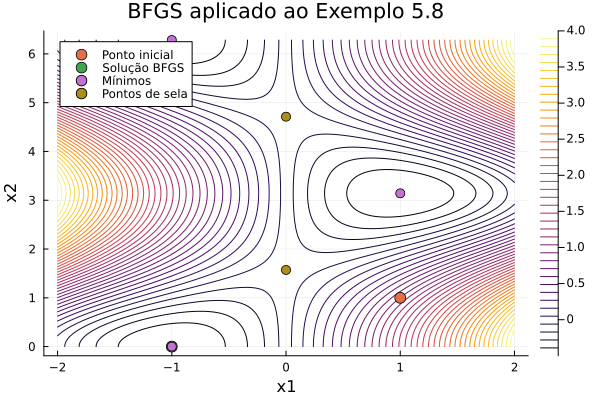

In [3]:
using LinearAlgebra
using Printf
using Plots

# Função do Exemplo 5.8
# f(x1,x2) = 1/2*x1^2 + x1*cos(x2)


function f(x)
    x1 = x[1]
    x2 = x[2]
    return 0.5*x1^2 + x1*cos(x2)
end


# Gradiente
# df/dx1 = x1 + cos(x2)
# df/dx2 = -x1*sin(x2)

function grad_f(x)
    x1 = x[1]
    x2 = x[2]

    return [
        x1 + cos(x2);
        -x1*sin(x2)
    ]
end

function hess_f(x)
    x1 = x[1]
    x2 = x[2]

    return [
        1.0        -sin(x2);
       -sin(x2)   -x1*cos(x2)
    ]
end

# Busca linear por Armijo
#
# Queremos garantir redução suficiente:
#
# f(x + αd) <= f(x) + c1*α*g'd


function busca_linear_armijo(x, d, g; α0=1.0, c1=1e-4, β=0.5, max_iter=50)
    α = α0
    fx = f(x)

    for i in 1:max_iter
        if f(x + α*d) <= fx + c1*α*dot(g, d)
            return α
        end

        α *= β
    end

    return α
end

# Método BFGS Quasi-Newton
#
# Hinv aproxima a inversa da Hessiana
# d = -Hinv * grad_f(x)

function bfgs(x0; ε=1e-8, max_iter=100)
    x = copy(x0)
    n = length(x)

    Hinv = Matrix{Float64}(I, n, n)

    println("Algoritmo 13.1 - Método Quasi-Newton BFGS")
    println("Ponto inicial: ", x0)
    println("Iteração |      x1       |      x2       |      f(x)      |   ||grad||   |   α")

    for k in 0:max_iter
        g = grad_f(x)
        norma_g = norm(g)

        @printf("%8d | %13.8f | %13.8f | %12.5e | %12.5e |",
                k, x[1], x[2], f(x), norma_g)

        if norma_g <= ε
            println("\n\nConvergência atingida.")
            return x
        end

        # Direção BFGS
        d = -Hinv * g

        # Se a direção não for de descida, reinicia Hinv
        if dot(g, d) >= 0
            Hinv = Matrix{Float64}(I, n, n)
            d = -g
        end

        # Busca linear
        α = busca_linear_armijo(x, d, g)

        @printf(" %8.4f\n", α)

        # Atualização do ponto
        x_novo = x + α*d

        # Vetores s e y
        s = x_novo - x
        y = grad_f(x_novo) - g

        ys = dot(y, s)

        # Atualização BFGS corrigida
        if ys > 1e-12
            ρ = 1.0 / ys
            Iden = Matrix{Float64}(I, n, n)

            Hinv = (Iden - ρ*s*y') * Hinv * (Iden - ρ*y*s') + ρ*(s*s')
        else
            println("Aviso: yᵀs <= 0. Reiniciando Hinv = I.")
            Hinv = Matrix{Float64}(I, n, n)
        end

        x = x_novo
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

function classificar_ponto(x)
    H = hess_f(x)
    autovalores = eigvals(H)

    println("Classificação do ponto")
    println("Hessiana real no ponto:")
    println(H)
    println("Determinante da Hessiana = ", det(H))
    println("Autovalores = ", autovalores)

    if all(autovalores .> 0)
        println("Conclusão: mínimo local.")
    elseif all(autovalores .< 0)
        println("Conclusão: máximo local.")
    elseif any(autovalores .> 0) && any(autovalores .< 0)
        println("Conclusão: ponto de sela.")
    else
        println("Conclusão: teste inconclusivo.")
    end
end


x0 = [1.0, 1.0]

x_sol = bfgs(x0, ε=1e-8, max_iter=100)

println("Resultado final")
println("x* = ", x_sol)
println("f(x*) = ", f(x_sol))
println("grad f(x*) = ", grad_f(x_sol))
println("||grad f(x*)|| = ", norm(grad_f(x_sol)))

classificar_ponto(x_sol)

println("Soluções estacionárias conhecidas")

println("Pontos de sela:")
println("(0, π/2 + kπ), k ∈ Z")

println("\nMínimos locais e globais:")
println("(-1, 2kπ), k ∈ Z")
println("(1, (2k+1)π), k ∈ Z")

println("\nValor mínimo global:")
println("f(x*) = -0.5")

pontos_iniciais = [
    [1.0, 1.0],
    [-1.0, 0.5],
    [2.0, 3.0],
    [-2.0, 3.0],
    [1.0, 4.0],
    [-1.0, 6.0],
    [0.5, 5.0]
]

println("Teste com vários pontos iniciais")


for x0_teste in pontos_iniciais
    println("\nPonto inicial: ", x0_teste)

    try
        x_resultado = bfgs(x0_teste, ε=1e-8, max_iter=100)

        println("Solução encontrada: ", x_resultado)
        println("f(x*) = ", f(x_resultado))
        println("||grad|| = ", norm(grad_f(x_resultado)))
        println("det(H) = ", det(hess_f(x_resultado)))

    catch e
        println("Erro: ", e)
    end
end


x1_vals = range(-2, 2, length=300)
x2_vals = range(0, 2π, length=300)

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

contour(
    x1_vals,
    x2_vals,
    Z,
    levels=40,
    xlabel="x1",
    ylabel="x2",
    title="BFGS aplicado ao Exemplo 5.8",
    label=false
)

# Ponto inicial
scatter!(
    [x0[1]],
    [x0[2]],
    label="Ponto inicial",
    markersize=6
)

# Solução encontrada
scatter!(
    [x_sol[1]],
    [x_sol[2]],
    label="Solução BFGS",
    markersize=6
)

# Mínimos dentro de 0 ≤ x2 ≤ 2π
scatter!(
    [-1.0, 1.0, -1.0],
    [0.0, π, 2π],
    label="Mínimos",
    markersize=5
)

# Pontos de sela dentro de 0 ≤ x2 ≤ 2π
scatter!(
    [0.0, 0.0],
    [π/2, 3π/2],
    label="Pontos de sela",
    markersize=5
)

#### the Rosenbrock problem

Algoritmo 13.1 - BFGS aplicado à função de Rosenbrock
Ponto inicial: [-1.2, 1.0]
Iteração |      x1       |      x2       |      f(x)      |   ||grad||   |   α
       0 |   -1.20000000 |    1.00000000 |  2.42000e+01 |  2.32868e+02 |   0.0010
       1 |   -0.98945312 |    1.08593750 |  5.10111e+00 |  4.38985e+01 |   0.1250
       2 |   -0.77234581 |    0.57059240 |  3.20842e+00 |  1.26642e+01 |   1.0000
       3 |   -0.74128547 |    0.51842587 |  3.12866e+00 |  1.41374e+01 |   1.0000
       4 |   -0.46315776 |    0.14171130 |  2.67087e+00 |  2.19418e+01 |   1.0000
       5 |   -0.49759059 |    0.26729175 |  2.28157e+00 |  4.04620e+00 |   1.0000
       6 |   -0.38197111 |    0.13390899 |  1.92423e+00 |  5.18454e+00 |   0.2500
       7 |   -0.30475090 |    0.05829363 |  1.82195e+00 |  9.71632e+00 |   1.0000
       8 |   -0.26165860 |    0.03613685 |  1.69629e+00 |  8.75766e+00 |   1.0000
       9 |   -0.12334990 |    0.00135220 |  1.28113e+00 |  4.03439e+00 |   0.5000
      10 |   -0.0311

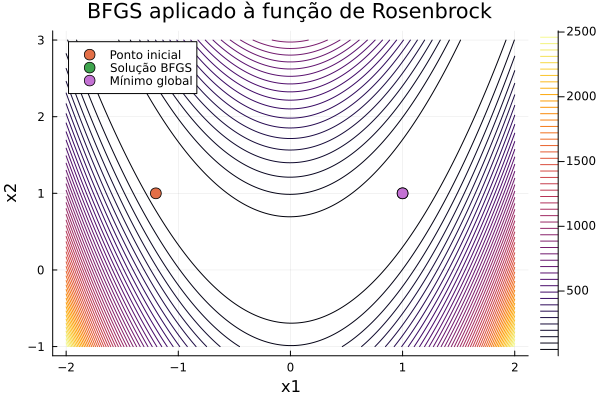

In [4]:
using LinearAlgebra
using Printf
using Plots

# Função de Rosenbrock
# f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2

function rosenbrock(x)
    x1 = x[1]
    x2 = x[2]

    return 100.0*(x2 - x1^2)^2 + (1.0 - x1)^2
end

# Gradiente da função de Rosenbrock
#
# df/dx1 = -400*x1*(x2 - x1^2) - 2*(1 - x1)
# df/dx2 = 200*(x2 - x1^2)

function grad_rosenbrock(x)
    x1 = x[1]
    x2 = x[2]

    return [
        -400.0*x1*(x2 - x1^2) - 2.0*(1.0 - x1);
         200.0*(x2 - x1^2)
    ]
end


# Hessiana real
# Usada apenas para classificar o ponto final

function hess_rosenbrock(x)
    x1 = x[1]
    x2 = x[2]

    return [
        1200.0*x1^2 - 400.0*x2 + 2.0    -400.0*x1;
        -400.0*x1                         200.0
    ]
end

# Busca linear de Armijo
#
# Condição:
# f(x + αd) <= f(x) + c1*α*gᵀd


function busca_linear_armijo_rosenbrock(x, d, g; α0=1.0, c1=1e-4, β=0.5, max_iter=50)
    α = α0
    fx = rosenbrock(x)

    for i in 1:max_iter
        if rosenbrock(x + α*d) <= fx + c1*α*dot(g, d)
            return α
        end

        α *= β
    end

    return α
end


# Método Quasi-Newton BFGS
#
# Hinv aproxima a inversa da Hessiana
# d_k = -Hinv * grad_f(x_k)


function bfgs_rosenbrock(x0; ε=1e-8, max_iter=100)
    x = copy(x0)
    n = length(x)

    Hinv = Matrix{Float64}(I, n, n)

    println("Algoritmo 13.1 - BFGS aplicado à função de Rosenbrock")
    println("Ponto inicial: ", x0)
    println("Iteração |      x1       |      x2       |      f(x)      |   ||grad||   |   α")

    for k in 0:max_iter
        g = grad_rosenbrock(x)
        norma_g = norm(g)

        @printf("%8d | %13.8f | %13.8f | %12.5e | %12.5e |",
                k, x[1], x[2], rosenbrock(x), norma_g)

        if norma_g <= ε
            println("\n\nConvergência atingida.")
            return x
        end

        # Direção quasi-Newton
        d = -Hinv * g

        # Se não for direção de descida, reinicia Hinv
        if dot(g, d) >= 0
            Hinv = Matrix{Float64}(I, n, n)
            d = -g
        end

        # Busca linear
        α = busca_linear_armijo_rosenbrock(x, d, g)

        @printf(" %8.4f\n", α)

        # Atualização do ponto
        x_novo = x + α*d

        # Vetores da atualização BFGS
        s = x_novo - x
        y = grad_rosenbrock(x_novo) - g

        ys = dot(y, s)

        if ys > 1e-12
            ρ = 1.0 / ys
            Iden = Matrix{Float64}(I, n, n)

            # Fórmula correta da atualização BFGS inversa
            Hinv = (Iden - ρ*s*y') * Hinv * (Iden - ρ*y*s') + ρ*(s*s')
        else
            println("Aviso: yᵀs <= 0. Reiniciando Hinv = I.")
            Hinv = Matrix{Float64}(I, n, n)
        end

        x = x_novo
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end


function classificar_rosenbrock(x)
    H = hess_rosenbrock(x)
    autovalores = eigvals(H)

    println("Classificação do ponto")
    println("Hessiana real no ponto:")
    println(H)
    println("Determinante da Hessiana = ", det(H))
    println("Autovalores = ", autovalores)

    if all(autovalores .> 0)
        println("Conclusão: mínimo local.")
    elseif all(autovalores .< 0)
        println("Conclusão: máximo local.")
    elseif any(autovalores .> 0) && any(autovalores .< 0)
        println("Conclusão: ponto de sela.")
    else
        println("Conclusão: teste inconclusivo.")
    end
end


x0 = [-1.2, 1.0]

x_sol = bfgs_rosenbrock(x0, ε=1e-8, max_iter=100)

println("Resultado final")
println("x* = ", x_sol)
println("f(x*) = ", rosenbrock(x_sol))
println("grad f(x*) = ", grad_rosenbrock(x_sol))
println("||grad f(x*)|| = ", norm(grad_rosenbrock(x_sol)))

classificar_rosenbrock(x_sol)

println("\nValor esperado teoricamente:")
println("x* = [1, 1]")
println("f(x*) = 0")


pontos_iniciais = [
    [-1.0, 1.0],
    [0.0, 0.0],
    [2.0, 2.0],
    [-2.0, 2.0]
]
println("Teste com vários pontos iniciais")

for x0_teste in pontos_iniciais
    println("\nPonto inicial: ", x0_teste)

    try
        x_resultado = bfgs_rosenbrock(x0_teste, ε=1e-8, max_iter=100)

        println("Solução encontrada: ", x_resultado)
        println("f(x*) = ", rosenbrock(x_resultado))
        println("||grad|| = ", norm(grad_rosenbrock(x_resultado)))
        println("det(H) = ", det(hess_rosenbrock(x_resultado)))

    catch e
        println("Erro: ", e)
    end
end

x1_vals = range(-2, 2, length=300)
x2_vals = range(-1, 3, length=300)

Z = [rosenbrock([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

contour(
    x1_vals,
    x2_vals,
    Z,
    levels=50,
    xlabel="x1",
    ylabel="x2",
    title="BFGS aplicado à função de Rosenbrock",
    label=false
)

# Ponto inicial
scatter!(
    [x0[1]],
    [x0[2]],
    label="Ponto inicial",
    markersize=6
)

# Solução encontrada
scatter!(
    [x_sol[1]],
    [x_sol[2]],
    label="Solução BFGS",
    markersize=6
)

# Mínimo global
scatter!(
    [1.0],
    [1.0],
    label="Mínimo global",
    markersize=6
)